# XGBoost Calibration: CTO_LINE + RSI Features

This notebook calibrates an XGBoost model using:
- **CTO Line features**: Long/short signals + relative distance from v1/v2 lines to close
- **RSI features**: Multiple period RSI indicators

After training, the `FittingJudge` evaluates calibration quality.

In [1]:
import sys
sys.path.insert(0, '/app')
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
import warnings
warnings.filterwarnings("ignore")

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Tuple, Dict, Any

from features.base_dataframe import BaseDataFrame
from features.features_utils import FeatureType
from features.targets_generators import gen_perfect_signal_class
from norm.norm_utils import load_normalized_df
from core.data_org import get_normalised_file, MktDataTFreq, ExchangeNAME, ProductType
from core.enums import g_high_col, g_low_col, g_close_col
from fitting.fitting_models import TrainingConfig, TimeSeriesModelTrainer
from fitting.fitting_core import TrainingSplitType, TaskType
from fitting.models import ModelFactory, ModelType
from fitting.fitting_judge import FittingJudge, ModelInfo, DataInfo

print("Imports loaded successfully")

Imports loaded successfully


## Configuration

In [3]:
# Data configuration
SYMBOL = "EURUSD"
DATA_PCT = 1.0  # Use 0.1 for quick testing
START_DATE = "20100103"
END_DATE = "20260226"

# CTO Line parameters (v1, m1, m2, v2)
CTO_PARAMS = (15, 19, 25, 29)

# RSI periods
RSI_PERIODS = [14, 60, 240]

# Target configuration
TARGET_PERIODS = 60  # Look-ahead periods for target

# Train/Val/Test split
TRAIN_RATIO = 0.6
VAL_RATIO = 0.2

print(f"Symbol: {SYMBOL}")
print(f"Data percentage: {DATA_PCT*100}%")
print(f"CTO params: {CTO_PARAMS}")
print(f"RSI periods: {RSI_PERIODS}")
print(f"Target periods: {TARGET_PERIODS}")
print(f"Train/Val/Test: {TRAIN_RATIO}/{VAL_RATIO}/{1-TRAIN_RATIO-VAL_RATIO}")

Symbol: EURUSD
Data percentage: 100.0%
CTO params: (15, 19, 25, 29)
RSI periods: [14, 60, 240]
Target periods: 60
Train/Val/Test: 0.6/0.2/0.2


## 1. Load Data

In [4]:
def load_data(p_symbol: str, p_data_pct: float, p_start: str, p_end: str) -> pd.DataFrame:
    """Load normalized OHLCV data."""
    try:
        path = get_normalised_file(
            MktDataTFreq.CANDLE_1MIN,
            ExchangeNAME.FIRSTRATE,
            ProductType.SPOT,
            p_symbol,
            p_start=p_start,
            p_end=p_end,
        )
        df = load_normalized_df(str(path)[4:])
        if p_data_pct < 1.0:
            n_rows = int(len(df) * p_data_pct)
            df = df.iloc[:n_rows].copy()
        return df
    except Exception as e:
        print(f"Error loading data: {e}")
        raise

In [5]:
SYMBOL

'EURUSD'

In [6]:
df = load_data(SYMBOL, DATA_PCT, START_DATE, END_DATE)
print(f"Loaded {len(df):,} rows for {SYMBOL}")
print(f"Columns: {list(df.columns[:10])}...")
df.head()

Loaded 5,985,614 rows for EURUSD
Columns: ['i_minute_i', 'S_open_f32', 'S_high_f32', 'S_low_f32', 'S_close_f32', 'S_volume_f64', 'S_open_time_i', 'S_close_time_i']...


,i_minute_i,S_open_f32,S_high_f32,S_low_f32,S_close_f32,S_volume_f64,S_open_time_i,S_close_time_i
0,5264220,1.43000,1.43008,1.42995,1.43007,21.0,2010-01-03 17:00:00,"20100103,17:00:00"
1,5264221,1.43008,1.43020,1.43008,1.43018,11.0,2010-01-03 17:01:00,"20100103,17:01:00"
2,5264222,1.43009,1.43014,1.42996,1.43014,22.0,2010-01-03 17:02:00,"20100103,17:02:00"
3,5264223,1.43010,1.43014,1.43010,1.43010,6.0,2010-01-03 17:03:00,"20100103,17:03:00"
4,5264224,1.43003,1.43009,1.42964,1.42989,35.0,2010-01-03 17:04:00,"20100103,17:04:00"


In [7]:
dfsaved = df.copy()

df = df [:10000]

In [8]:
df.columns


Index(['i_minute_i', 'S_open_f32', 'S_high_f32', 'S_low_f32', 'S_close_f32',
       'S_volume_f64', 'S_open_time_i', 'S_close_time_i'],
      dtype='str')

## 2. Build Features

Features include:
- **CTO Line**: `F_cto_line_long_f16`, `F_cto_line_short_f16`, `F_cto_line_v1_rel_dist_f16`, `F_cto_line_v2_rel_dist_f16`
- **RSI**: `F_rsi_{period}_f16` for each period

In [9]:
def build_features(p_df: pd.DataFrame, p_cto_params: Tuple, p_rsi_periods: list) -> Tuple[pd.DataFrame, list]:
    """Build CTO_line and RSI features."""
    bdf = BaseDataFrame(p_df=p_df.copy())
    
    bdf.add_feature(FeatureType.CTO_LINE, params=p_cto_params)
    bdf.add_feature(FeatureType.RSI, periods=p_rsi_periods)
    
    df = bdf.get_dataframe()
    
    cto_cols = [c for c in df.columns if "cto_line" in c.lower()]
    rsi_cols = [c for c in df.columns if "rsi" in c.lower() and c.startswith("F_")]
    feature_cols = cto_cols + rsi_cols
    
    return df, feature_cols

features_df, feature_cols = build_features(df, CTO_PARAMS, RSI_PERIODS)

print(f"Built {len(feature_cols)} features:")
for col in feature_cols:
    print(f"  - {col}")

Built 7 features:
  - F_cto_line_long_f16
  - F_cto_line_short_f16
  - F_cto_line_v1_rel_dist_f16
  - F_cto_line_v2_rel_dist_f16
  - F_rsi_14_F_mid_f32_f16
  - F_rsi_60_F_mid_f32_f16
  - F_rsi_240_F_mid_f32_f16


In [10]:
# Inspect CTO line features
cto_cols = [c for c in feature_cols if 'cto' in c.lower()]
print("CTO Line Features Summary:")
features_df[cto_cols].describe()

CTO Line Features Summary:


,F_cto_line_long_f16,F_cto_line_short_f16,F_cto_line_v1_rel_dist_f16,F_cto_line_v2_rel_dist_f16
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.406300,0.442800,-0.000016,-0.000033
std,0.491166,0.496742,0.000474,0.000654
min,0.000000,0.000000,-0.004368,-0.005553
25%,0.000000,0.000000,-0.000232,-0.000311
50%,0.000000,0.000000,0.000003,0.000014
75%,1.000000,1.000000,0.000240,0.000315
max,1.000000,1.000000,0.003497,0.003752


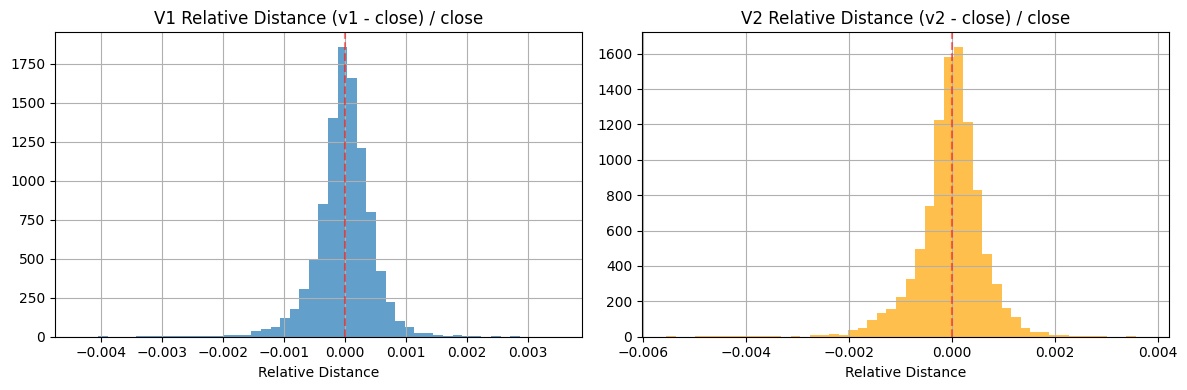

In [11]:
# Visualize relative distance distributions
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

v1_col = 'F_cto_line_v1_rel_dist_f16'
v2_col = 'F_cto_line_v2_rel_dist_f16'

if v1_col in features_df.columns:
    features_df[v1_col].hist(bins=50, ax=axes[0], alpha=0.7)
    axes[0].set_title('V1 Relative Distance (v1 - close) / close')
    axes[0].set_xlabel('Relative Distance')
    axes[0].axvline(0, color='red', linestyle='--', alpha=0.5)

if v2_col in features_df.columns:
    features_df[v2_col].hist(bins=50, ax=axes[1], alpha=0.7, color='orange')
    axes[1].set_title('V2 Relative Distance (v2 - close) / close')
    axes[1].set_xlabel('Relative Distance')
    axes[1].axvline(0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 3. Build Targets

Target: Perfect signal classification over N periods

In [20]:
def build_targets(p_df: pd.DataFrame, p_n_periods: int) -> Tuple[pd.DataFrame, str]:
    """Build classification target."""
    signal, signal_name = gen_perfect_signal_class(
        df=p_df,
        close_col=g_close_col,
        high_col=g_high_col,
        low_col=g_low_col,
        upstrong_val=0.05,
        downstrong_val=-0.08,
        flat_val=0.002,
        N_periods=p_n_periods,
    )
    
    target_df = pd.DataFrame(index=p_df.index)
    target_col = f"T_{signal_name}"
    target_df[target_col] = signal
    
    return target_df, target_col

target_df, target_col = build_targets(features_df, TARGET_PERIODS)

print(f"Target column: {target_col}")
print(f"\nTarget distribution:")
print(target_df[target_col].value_counts())

from features.signals_utils import map_minus1_0_1_to_0_1_2,map_P_to_N

map_P_to_N(target_df,target_col,

Target column: T_PerfectClass_N60

Target distribution:
T_PerfectClass_N60
 0    7674
 1    1412
-1     914
Name: count, dtype: int64


(      T_PerfectClass_N60
 0                      1
 1                      1
 2                      1
 3                      1
 4                      1
 ...                  ...
 9995                   0
 9996                   0
 9997                   0
 9998                   0
 9999                   0
 
 [10000 rows x 1 columns],
 'T_PerfectClass_N60')

## 4. Prepare X/y Matrices

In [16]:
def prepare_xy(
    p_features_df: pd.DataFrame,
    p_feature_cols: list,
    p_target_df: pd.DataFrame,
    p_target_col: str,
    p_valid_col: str = "valid_row",
) -> Tuple[np.ndarray, np.ndarray]:
    """Prepare X and y arrays."""
    combined = pd.concat([p_features_df[p_feature_cols], p_target_df[[p_target_col]]], axis=1)
    
    if p_valid_col in p_features_df.columns:
        combined[p_valid_col] = p_features_df[p_valid_col]
        combined = combined[combined[p_valid_col] == True]
    
    combined = combined.dropna()
    
    X = combined[p_feature_cols].values.astype(np.float32)
    y = combined[p_target_col].values.astype(np.float32)
    
    return X, y

X, y = prepare_xy(features_df, feature_cols, target_df, target_col)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFeature columns ({len(feature_cols)}): {feature_cols}")

X shape: (9888, 7)
y shape: (9888,)

Feature columns (7): ['F_cto_line_long_f16', 'F_cto_line_short_f16', 'F_cto_line_v1_rel_dist_f16', 'F_cto_line_v2_rel_dist_f16', 'F_rsi_14_F_mid_f32_f16', 'F_rsi_60_F_mid_f32_f16', 'F_rsi_240_F_mid_f32_f16']


## 5. Train XGBoost Model with FittingJudge

In [17]:
def train_xgb_model(
    X: np.ndarray,
    y: np.ndarray,
    p_feature_cols: list,
    p_target_col: str,
    p_task_type: TaskType = TaskType.CLASSIFICATION,
    p_train_ratio: float = 0.6,
    p_val_ratio: float = 0.2,
    p_verbose: bool = True,
) -> Dict[str, Any]:
    """Train XGBoost model with FittingJudge evaluation."""
    config = TrainingConfig(
        mode=TrainingSplitType.TRAIN_VAL_TEST,
        train_ratio=p_train_ratio,
        val_ratio=p_val_ratio,
        normalization="standardize",
    )
    
    model = ModelFactory.create_model(ModelType.XGB, p_task_type)
    trainer = TimeSeriesModelTrainer(model, config, p_task_type)
    
    metrics = trainer.fit(X, y)
    
    n_samples = len(X)
    model_info = ModelInfo(
        model_type="XGBoost",
        task_type=p_task_type,
        params=model.get_params() if hasattr(model, 'get_params') else {},
        model_class=ModelType.XGB.value,
    )
    data_info = DataInfo(
        n_samples=n_samples,
        n_features=len(p_feature_cols),
        feature_names=p_feature_cols,
        target_name=p_target_col,
        train_size=int(n_samples * p_train_ratio),
        val_size=int(n_samples * p_val_ratio),
        test_size=int(n_samples * (1 - p_train_ratio - p_val_ratio)),
    )
    
    judge = FittingJudge(metrics, model_info, data_info, config)
    verdict = judge.evaluate()
    
    if p_verbose:
        print("="*60)
        print("XGBoost Training Results")
        print("="*60)
        print(f"Train score: {metrics.train_score:.4f}")
        if metrics.val_score is not None:
            print(f"Val score:   {metrics.val_score:.4f}")
        if metrics.test_score is not None:
            print(f"Test score:  {metrics.test_score:.4f}")
        print("="*60)
    
    return {
        "model": model,
        "trainer": trainer,
        "metrics": metrics,
        "verdict": verdict,
    }

results = train_xgb_model(
    X=X,
    y=y,
    p_feature_cols=feature_cols,
    p_target_col=target_col,
    p_task_type=TaskType.CLASSIFICATION,
    p_train_ratio=TRAIN_RATIO,
    p_val_ratio=VAL_RATIO,
)

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2], got [-1.  0.  1.]

## 6. FittingJudge Verdict

In [ ]:
verdict = results["verdict"]

print("="*60)
print("FITTING JUDGE VERDICT")
print("="*60)
print(f"Rating: {verdict.rating.value.upper()}")
print(f"Score:  {verdict.score:.2%}")
print(f"\nSummary:")
print(verdict.summary)

In [ ]:
if verdict.issues:
    print("\n" + "="*60)
    print("ISSUES DETECTED")
    print("="*60)
    for issue in verdict.issues:
        print(f"\n[{issue.severity.upper()}] {issue.type.value}")
        print(f"  Message: {issue.message}")
        if issue.details:
            print(f"  Details: {issue.details}")
else:
    print("\nNo issues detected!")

In [ ]:
if verdict.recommendations:
    print("\n" + "="*60)
    print("RECOMMENDATIONS")
    print("="*60)
    for i, rec in enumerate(verdict.recommendations, 1):
        print(f"{i}. {rec}")

## 7. Experiment: Different CTO Parameters

Try different CTO parameters to see impact on model performance.

In [ ]:
def run_experiment(p_cto_params: Tuple, p_symbol: str = SYMBOL, p_data_pct: float = 0.5) -> Dict:
    """Run calibration experiment with given parameters."""
    print(f"\nTesting CTO params: {p_cto_params}")
    print("-" * 40)
    
    # Load data
    df = load_data(p_symbol, p_data_pct, START_DATE, END_DATE)
    
    # Build features
    features_df, feature_cols = build_features(df, p_cto_params, RSI_PERIODS)
    
    # Build targets
    target_df, target_col = build_targets(features_df, TARGET_PERIODS)
    
    # Prepare X/y
    X, y = prepare_xy(features_df, feature_cols, target_df, target_col)
    
    # Train
    results = train_xgb_model(
        X=X, y=y,
        p_feature_cols=feature_cols,
        p_target_col=target_col,
        p_task_type=TaskType.CLASSIFICATION,
        p_train_ratio=TRAIN_RATIO,
        p_val_ratio=VAL_RATIO,
        p_verbose=False,
    )
    
    verdict = results["verdict"]
    metrics = results["metrics"]
    
    print(f"  Train: {metrics.train_score:.4f}")
    print(f"  Val:   {metrics.val_score:.4f if metrics.val_score else 'N/A'}")
    print(f"  Test:  {metrics.test_score:.4f if metrics.test_score else 'N/A'}")
    print(f"  Judge: {verdict.rating.value} ({verdict.score:.2%})")
    
    return {
        "cto_params": p_cto_params,
        "train_score": metrics.train_score,
        "val_score": metrics.val_score,
        "test_score": metrics.test_score,
        "verdict_rating": verdict.rating.value,
        "verdict_score": verdict.score,
        "issues_count": len(verdict.issues),
    }

# Run experiments with different parameters
experiments = [
    (15, 19, 25, 29),  # Default
    (10, 15, 20, 25),  # Faster
    (20, 25, 35, 40),  # Slower
]

results_list = []
for params in experiments:
    try:
        result = run_experiment(params)
        results_list.append(result)
    except Exception as e:
        print(f"  Error: {e}")

# Summary
print("\n" + "="*60)
print("EXPERIMENT SUMMARY")
print("="*60)
summary_df = pd.DataFrame(results_list)
summary_df

## Summary

This notebook demonstrated:
1. Loading normalized forex data
2. Building CTO Line features with **relative distance columns**
3. Building RSI features
4. Training XGBoost classifier
5. Evaluating calibration quality with **FittingJudge**
6. Running parameter experiments